In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.colors import LogNorm

In [2]:
def draw_court(ax):
    line_color = "white"
    lw = 2.0
    alpha = 0.95

    court_elements = [
        Circle((0, 0), radius=7.5, fill=False, color=line_color, lw=lw, alpha=alpha),
        Rectangle((-30, -7.5), 60, -1, fill=False, color=line_color, lw=lw, alpha=alpha),
        Rectangle((-80, -47.5), 160, 190, fill=False, color=line_color, lw=lw, alpha=alpha),
        Arc((0, 142.5), 120, 120, theta1=0, theta2=180, color=line_color, lw=lw, alpha=alpha),
        Arc((0, 0), 475, 475, theta1=22, theta2=158, color=line_color, lw=lw, alpha=alpha),
        Rectangle((-220, -47.5), 0, 140, fill=False, color=line_color, lw=lw, alpha=alpha),
        Rectangle((220, -47.5), 0, 140, fill=False, color=line_color, lw=lw, alpha=alpha),
        Rectangle((-250, -47.5), 500, 470, fill=False, color=line_color, lw=lw, alpha=alpha)
    ]

    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.set_aspect("equal")
    ax.axis("off")

In [3]:
# Research Question 1

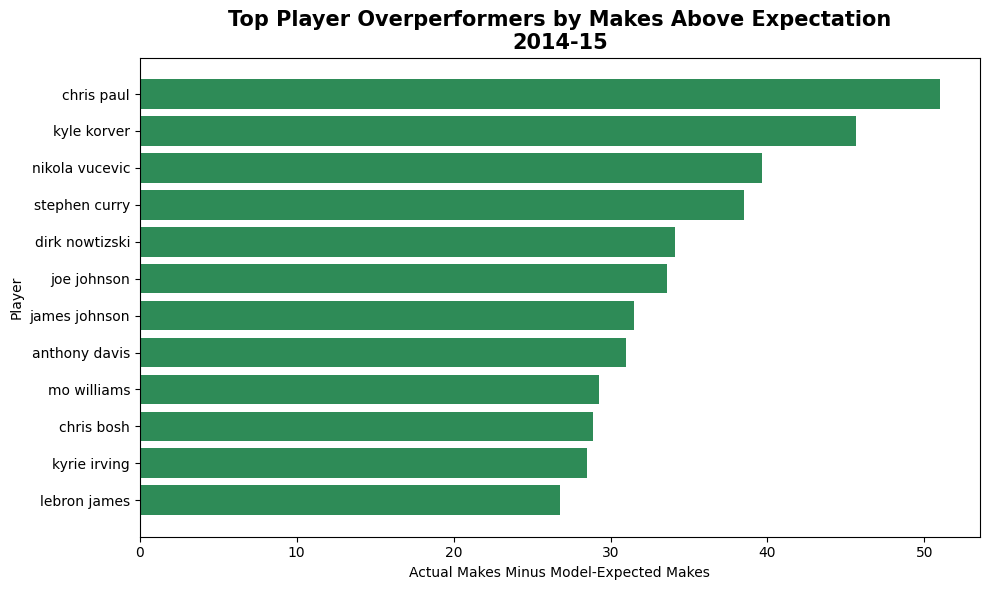

In [4]:
player_residuals = pd.read_csv("data/model_outputs/player_residuals.csv")

top_players = player_residuals.head(12).sort_values("makes_above_expected")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_players["player_name"],
    top_players["makes_above_expected"],
    color="seagreen"
)

ax.set_title(
    "Top Player Overperformers by Makes Above Expectation\n2014-15",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Actual Makes Minus Model-Expected Makes")
ax.set_ylabel("Player")

plt.tight_layout()
plt.show()

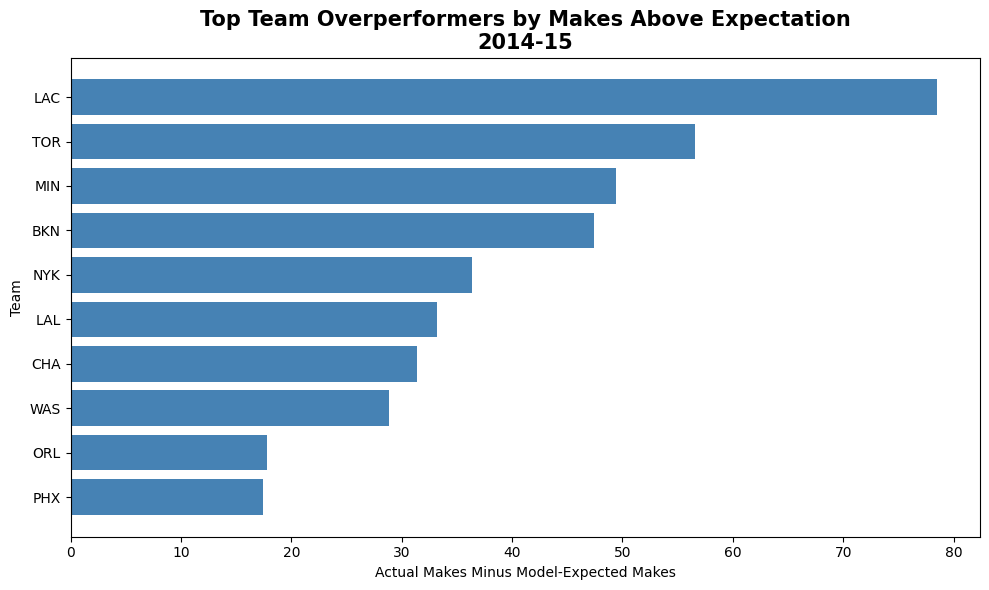

In [5]:
team_residuals = pd.read_csv("data/model_outputs/team_residuals.csv")

top_teams = team_residuals.head(10).sort_values("makes_above_expected")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_teams["SHOOTING_TEAM"],
    top_teams["makes_above_expected"],
    color="steelblue"
)

ax.set_title(
    "Top Team Overperformers by Makes Above Expectation\n2014-15",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Actual Makes Minus Model-Expected Makes")
ax.set_ylabel("Team")

plt.tight_layout()
plt.show()

In [6]:
# Research Question 2

In [7]:
shots_2013 = pd.read_parquet("data/raw/shots/shots_2013-14.parquet")
shots_2019 = pd.read_parquet("data/raw/shots/shots_2019-20.parquet")
shots_2025 = pd.read_parquet("data/raw/shots/shots_2025-26.parquet")

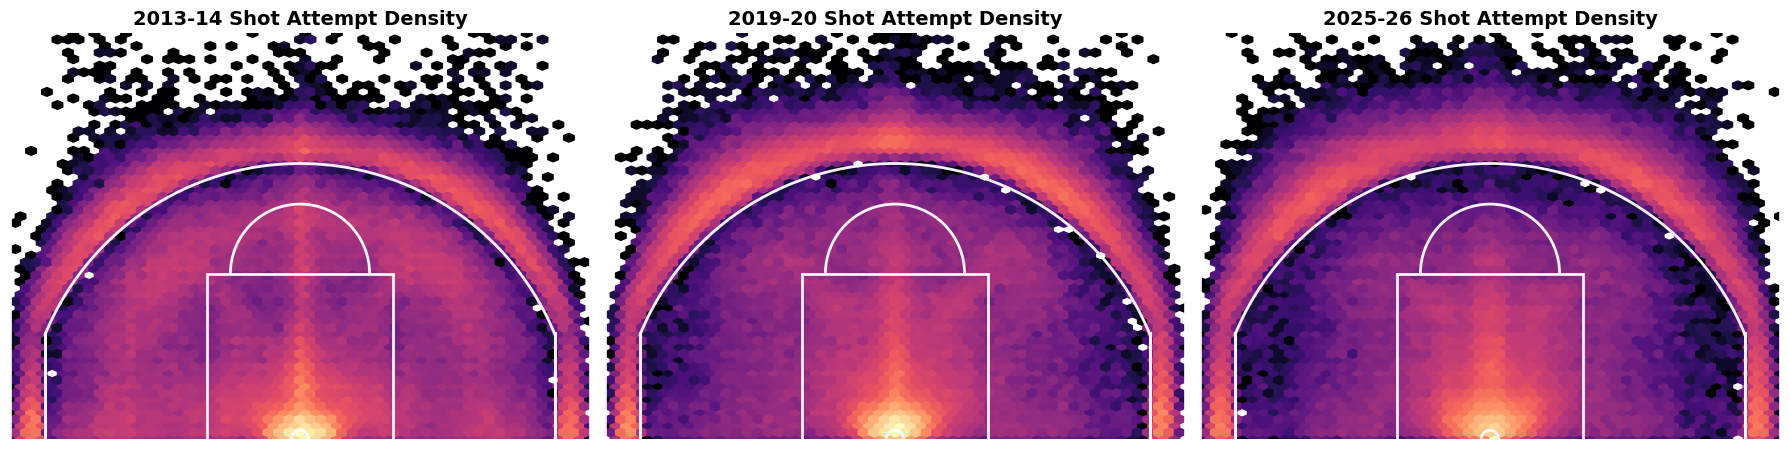

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

season_data = {
    "2013-14": shots_2013,
    "2019-20": shots_2019,
    "2025-26": shots_2025
}

for ax, (season, df) in zip(axes, season_data.items()):

    df = df[(df["LOC_Y"] >= 0) & (df["LOC_Y"] <= 350)]

    ax.hexbin(
        df["LOC_X"],
        df["LOC_Y"],
        gridsize=55,
        cmap="magma",
        mincnt=0,
        norm=LogNorm()
    )

    draw_court(ax)

    ax.set_title(
        f"{season} Shot Attempt Density",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlim(-250, 250)
    ax.set_ylim(0, 350)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

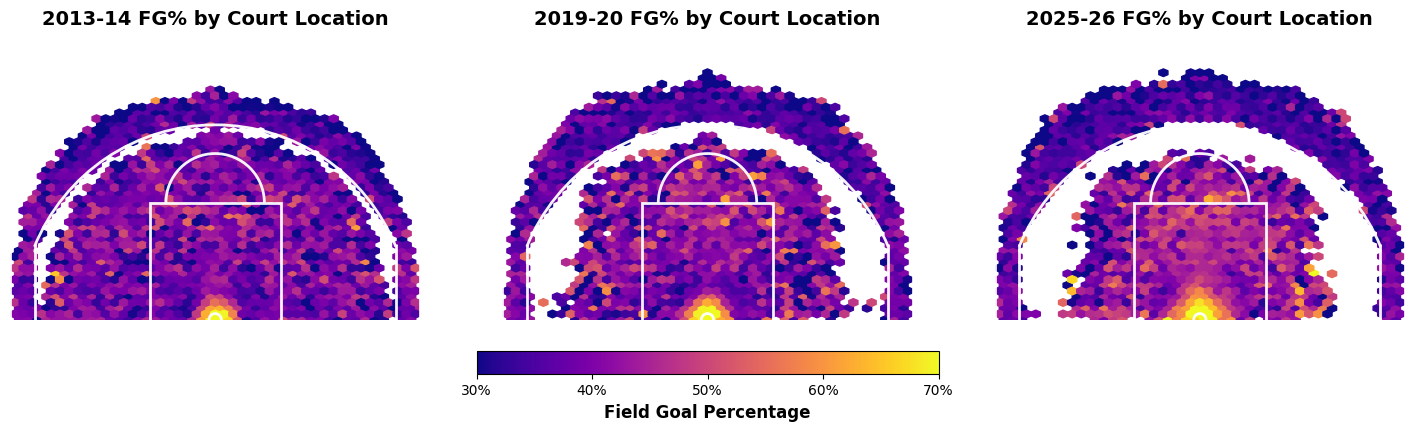

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

season_data = {
    "2013-14": shots_2013,
    "2019-20": shots_2019,
    "2025-26": shots_2025
}

hb = None

for ax, (season, df) in zip(axes, season_data.items()):

    df = df[(df["LOC_Y"] >= 0) & (df["LOC_Y"] <= 350)].copy()

    hb = ax.hexbin(df["LOC_X"], df["LOC_Y"], C=df["SHOT_MADE_FLAG"], reduce_C_function=np.mean, gridsize=45, cmap="plasma", mincnt=20, vmin=0.3, vmax=0.7)

    draw_court(ax)

    ax.set_title(
        f"{season} FG% by Court Location",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlim(-250, 250)
    ax.set_ylim(0, 350)
    ax.set_aspect("equal")
    ax.axis("off")


cbar = fig.colorbar(
    hb,
    ax=axes,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05
)

cbar.set_label(
    "Field Goal Percentage",
    fontsize=12,
    fontweight="bold"
)

cbar.set_ticks([0.30, 0.40, 0.50, 0.60, 0.70])
cbar.set_ticklabels(["30%", "40%", "50%", "60%", "70%"])

plt.subplots_adjust(bottom=0.20)
plt.show()

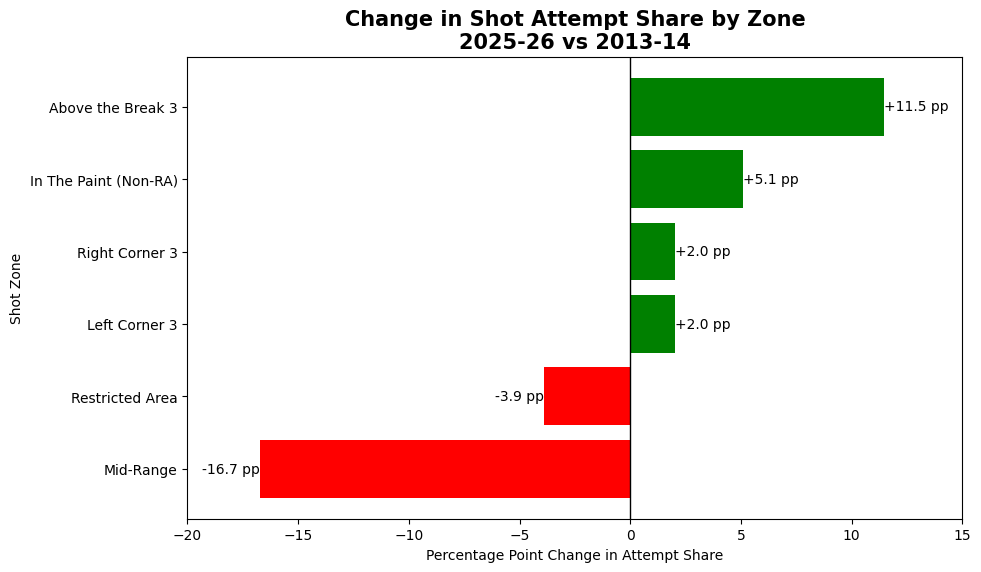

In [10]:
# Zone-level shot attempt change: 2025-26 vs 2013-14

zone_summary = []

for season, df in {
    "2013-14": shots_2013,
    "2025-26": shots_2025
}.items():

    df = df[df["SHOT_ZONE_BASIC"] != "Backcourt"].copy()

    zone_counts = (
        df["SHOT_ZONE_BASIC"]
        .value_counts(normalize=True)
        .mul(100)
    )

    for zone, pct in zone_counts.items():
        zone_summary.append({
            "Season": season,
            "Zone": zone,
            "Attempt %": pct
        })

zone_summary = pd.DataFrame(zone_summary)

zone_change = (
    zone_summary
    .pivot(index="Zone", columns="Season", values="Attempt %")
)

zone_change["Attempt % Change"] = (
    zone_change["2025-26"] - zone_change["2013-14"]
)

plot_df = zone_change.sort_values("Attempt % Change")

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "green" if x > 0 else "red"
    for x in plot_df["Attempt % Change"]
]

bars = ax.barh(
    plot_df.index,
    plot_df["Attempt % Change"],
    color=colors
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Change in Shot Attempt Share by Zone\n2025-26 vs 2013-14",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Percentage Point Change in Attempt Share")
ax.set_ylabel("Shot Zone")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:+.1f} pp",
        va="center",
        ha="left" if width > 0 else "right"
    )

ax.set_xlim(-20, 15)
plt.show()

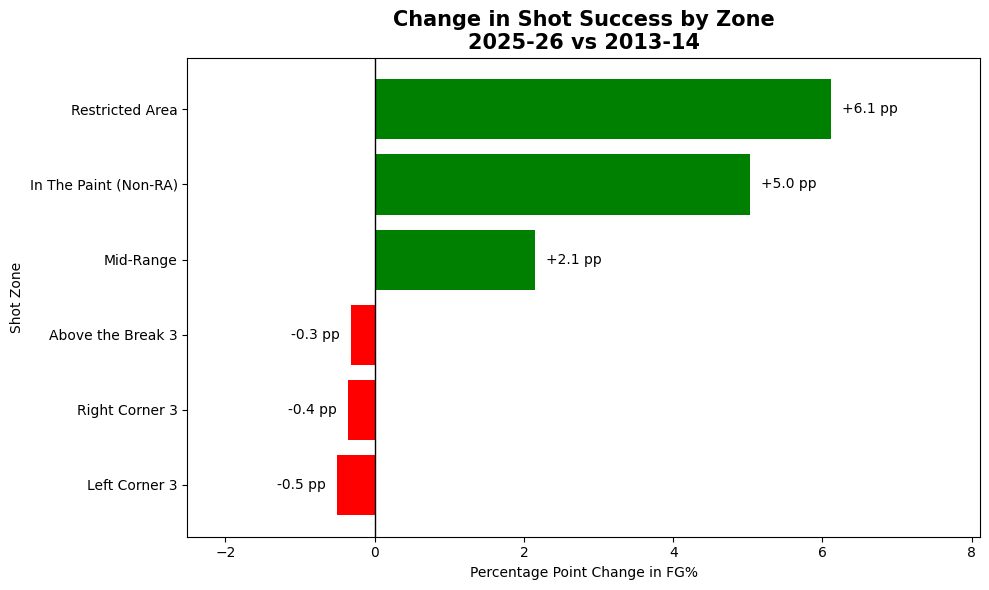

In [11]:
# Zone-level FG% change: 2025-26 vs 2013-14

fg_summary = []

for season, df in {
    "2013-14": shots_2013,
    "2025-26": shots_2025
}.items():

    df = df[df["SHOT_ZONE_BASIC"] != "Backcourt"].copy()

    zone_fg = (
        df.groupby("SHOT_ZONE_BASIC")["SHOT_MADE_FLAG"]
        .mean()
        .mul(100)
    )

    for zone, fg_pct in zone_fg.items():
        fg_summary.append({
            "Season": season,
            "Zone": zone,
            "FG%": fg_pct
        })

fg_summary = pd.DataFrame(fg_summary)

fg_change = (
    fg_summary
    .pivot(index="Zone", columns="Season", values="FG%")
)

fg_change["FG% Change"] = (
    fg_change["2025-26"] - fg_change["2013-14"]
)

plot_df = fg_change.sort_values("FG% Change")

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "green" if x > 0 else "red"
    for x in plot_df["FG% Change"]
]

bars = ax.barh(
    plot_df.index,
    plot_df["FG% Change"],
    color=colors
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Change in Shot Success by Zone\n2025-26 vs 2013-14",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Percentage Point Change in FG%")
ax.set_ylabel("Shot Zone")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.15 if width > 0 else width - 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{width:+.1f} pp",
        va="center",
        ha="left" if width > 0 else "right"
    )

ax.set_xlim(
    plot_df["FG% Change"].min() - 2,
    plot_df["FG% Change"].max() + 2
)

plt.tight_layout()
plt.show()

In [12]:
# Research Question 3

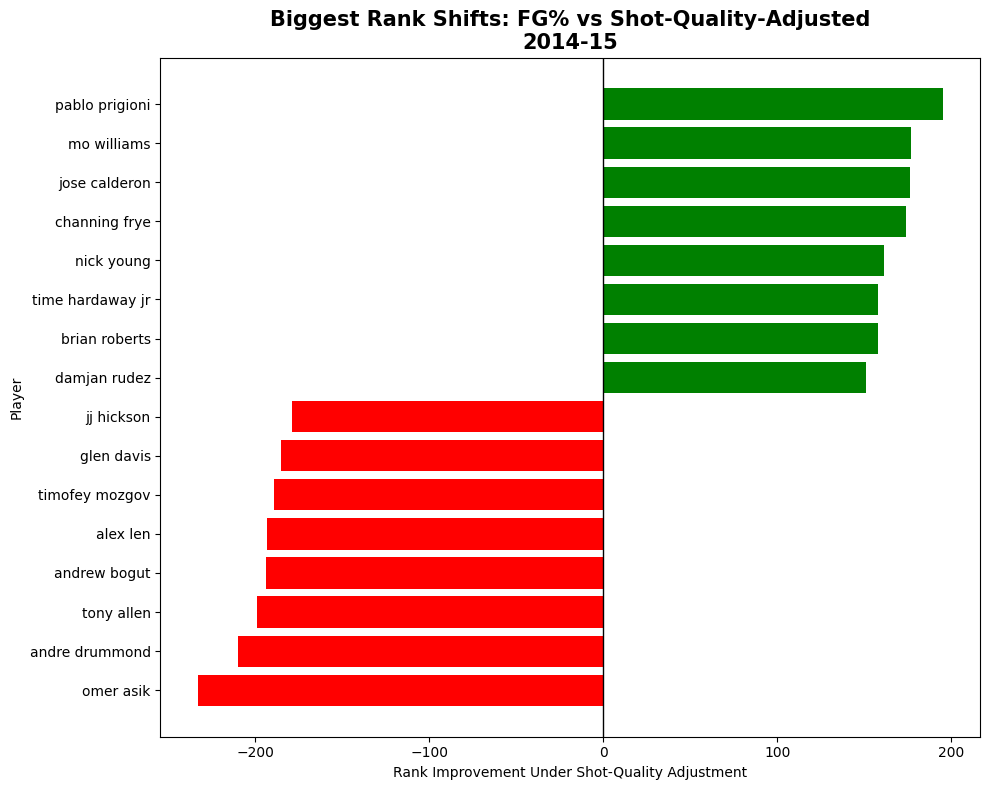

In [13]:
rank_table = pd.read_csv("data/model_outputs/rank_table.csv")

movers = pd.concat([
    rank_table.nlargest(8, "rank_shift_vs_fg"),
    rank_table.nsmallest(8, "rank_shift_vs_fg")
]).sort_values("rank_shift_vs_fg")

fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    "green" if x > 0 else "red"
    for x in movers["rank_shift_vs_fg"]
]

ax.barh(
    movers["player_name"],
    movers["rank_shift_vs_fg"],
    color=colors
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Biggest Rank Shifts: FG% vs Shot-Quality-Adjusted\n2014-15",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Rank Improvement Under Shot-Quality Adjustment")
ax.set_ylabel("Player")

plt.tight_layout()
plt.show()

In [14]:
# Model Performance

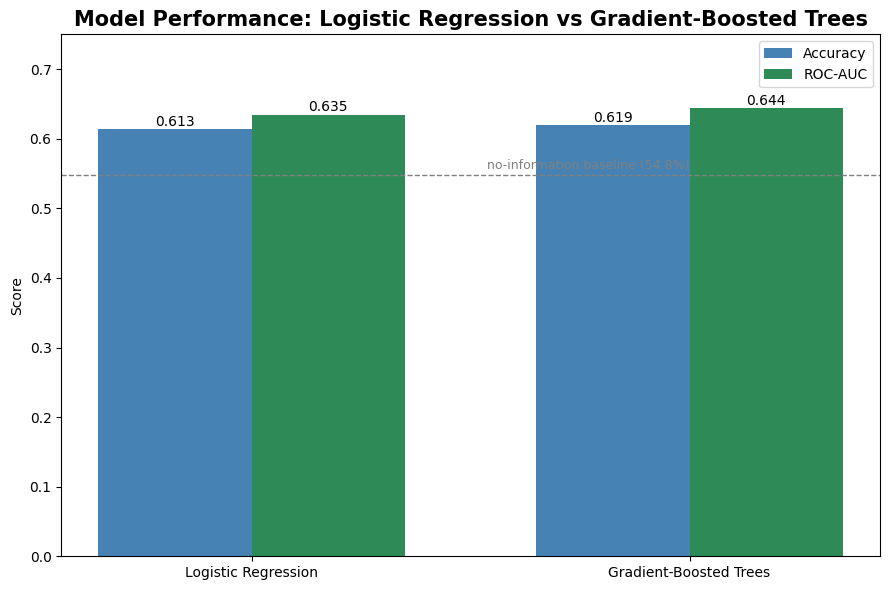

In [15]:
model_metrics = pd.read_csv("data/model_outputs/model_metrics.csv")

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(model_metrics))
width = 0.35

ax.bar(x - width / 2, model_metrics["accuracy"], width, label="Accuracy", color="steelblue")
ax.bar(x + width / 2, model_metrics["roc_auc"], width, label="ROC-AUC", color="seagreen")

for i, row in model_metrics.iterrows():
    ax.text(i - width / 2, row["accuracy"] + 0.005, f"{row['accuracy']:.3f}", ha="center")
    ax.text(i + width / 2, row["roc_auc"] + 0.005, f"{row['roc_auc']:.3f}", ha="center")

ax.axhline(0.548, linestyle="--", color="gray", linewidth=1)
ax.text(len(model_metrics) - 1, 0.557, "no-information baseline (54.8%)", ha="right", fontsize=9, color="gray")

ax.set_xticks(x)
ax.set_xticklabels(model_metrics["model"])
ax.set_ylim(0, 0.75)

ax.set_title(
    "Model Performance: Logistic Regression vs Gradient-Boosted Trees",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Score")
ax.legend()

plt.tight_layout()
plt.show()